---
title: "🧮 Thresholds, Utility and Confusion Matrices"
author: "Maksim Ohvrill"
date: "4/28/2025"
format:
  html:
    toc: true
    toc-location: right
    code-fold: true
bibliography: references.bib
csl: ieee-with-url.csl
jupyter: Python
---

This evaluation compares the decision utility of the CNN and Inferno, both operating on raw logits. For the CNN, utility is assessed using two thresholds: the commonly used default and a threshold optimized on the same training set that was used to train the Inferno model. Inferno’s utility is derived from its calibrated probabilistic output. All comparisons are conducted using a fixed utility matrix, constructed based on findings from clinical research literature.

## **Load data for evaluation**

In [10]:
import torch
import numpy as np
import pandas as pd
from rich import print
from torch.nn import BCEWithLogitsLoss

from CNN import CALIB_DIR


def load_logits_and_calculate_loss(csv_path):
    df = pd.read_csv(csv_path)

    logits = df[["LOGIT_EFFUSION", "LOGIT_ATELECTASIS"]].to_numpy(dtype="float32")
    labels = df[["LABEL_EFFUSION", "LABEL_ATELECTASIS"]].to_numpy(dtype="float32")

    logits_tensor = torch.tensor(logits)
    labels_tensor = torch.tensor(labels)

    loss_fn = BCEWithLogitsLoss()
    avg_loss = loss_fn(logits_tensor, labels_tensor).item()

    return df, logits_tensor, labels_tensor, avg_loss


df_full, preds_full, targets_full, loss_full = load_logits_and_calculate_loss(
    CALIB_DIR / "calibration_full.csv"
)

df_train, preds_train, targets_train, loss_train = load_logits_and_calculate_loss(
    CALIB_DIR / "calibration_train.csv"
)

df_test, preds_test, targets_test, loss_test = load_logits_and_calculate_loss(
    CALIB_DIR / "calibration_test.csv"
)

## **Find best threshold from Training Set**

In [ ]:
utility_matrix = np.array([
    [1.00, 0.55, 0.60, 0.40],
    [0.90, 0.60, 0.65, 0.75],
    [0.90, 0.65, 0.60, 0.75],
    [0.80, 0.85, 0.85, 0.60],
])

label_index = lambda e, a: e + 2 * a

def find_best_threshold(preds_tensor, targets_tensor, avg_loss):
    probs = torch.sigmoid(preds_tensor).numpy()
    targets = targets_tensor.numpy()

    print("\n--- Threshold Search on Train Set ---")
    print(f"Train BCEWithLogitsLoss: {avg_loss:.4f}")

    thresholds = np.linspace(0.1, 0.9, 81)
    best_utility = -1
    best_threshold = 0.5

    for threshold in thresholds:
        decisions_util = []
        true_vals_util = []
        for prob_vec, true_vec in zip(probs, targets):
            pred_bin = (prob_vec > threshold).astype(int)
            true_bin = true_vec.astype(int)

            pred_idx = int(label_index(pred_bin[0], pred_bin[1]))
            true_idx = int(label_index(true_bin[0], true_bin[1]))

            decisions_util.append(pred_idx)
            true_vals_util.append(true_idx)

        avg_utility = np.mean([utility_matrix[p, t] for p, t in zip(decisions_util, true_vals_util)])

        if avg_utility > best_utility:
            best_utility = avg_utility
            best_threshold = threshold

        if threshold == 0.5:
            print(f"Utility Score at Threshold 0.50: {avg_utility:.4f}")

    print(f"\nBest Threshold for Utility: {best_threshold:.2f}")
    print(f"Utility Score (Train Set): {best_utility:.4f}")

    return best_threshold


best_thresh = find_best_threshold(preds_train, targets_train, loss_train)

--- Threshold Search on Train Set ---

Train BCEWithLogitsLoss: 0.4301

Utility Score at Threshold 0.50: 0.8939

Best Threshold for Utility: 0.28

Utility Score (Train Set): 0.9131

## **Evaluate CNN (sigmoid) on test set with best threshold derived from Train Set**

In [12]:
def evaluate_at_threshold(preds_tensor, targets_tensor, threshold, avg_loss):
    probs = torch.sigmoid(preds_tensor).numpy()
    targets = targets_tensor.numpy()

    print(f"\n--- Evaluation at Threshold {threshold:.2f} ---")
    print(f"Test BCEWithLogitsLoss: {avg_loss:.4f}")

    decisions_util = []
    true_vals_util = []

    for prob_vec, true_vec in zip(probs, targets):
        pred_bin = (prob_vec > threshold).astype(int)
        true_bin = true_vec.astype(int)

        pred_idx = int(label_index(pred_bin[0], pred_bin[1]))
        true_idx = int(label_index(true_bin[0], true_bin[1]))

        decisions_util.append(pred_idx)
        true_vals_util.append(true_idx)

    avg_utility = np.mean([utility_matrix[p, t] for p, t in zip(decisions_util, true_vals_util)])

    # Utility score with best threshold from train set 
    print(f"Utility (Test Set): {avg_utility:.4f}")
    return probs, targets


kde_probs, scatter_targets = evaluate_at_threshold(preds_test, targets_test, best_thresh, loss_test)


--- Evaluation at Threshold 0.28 ---

Test BCEWithLogitsLoss: 0.4488

Utility (Test Set): 0.9077

## **Calculate and print confussion matrices for thresholds**

In [13]:
def print_confusion_matrices(preds_tensor, targets_tensor, best_threshold):
    probs = torch.sigmoid(preds_tensor).numpy()
    targets = targets_tensor.numpy()

    thresholds = [0.5, best_threshold]
    rows = []

    for thresh in thresholds:
        for i, disease in enumerate(["Effusion", "Atelectasis"]):
            preds_bin = (probs[:, i] > thresh).astype(int)
            true_bin = targets[:, i].astype(int)

            tp = int(((preds_bin == 1) & (true_bin == 1)).sum())
            fp = int(((preds_bin == 1) & (true_bin == 0)).sum())
            fn = int(((preds_bin == 0) & (true_bin == 1)).sum())
            tn = int(((preds_bin == 0) & (true_bin == 0)).sum())

            rows.append({
                "Threshold": round(thresh, 2),
                "Disease": disease,
                "TP": tp,
                "FP": fp,
                "FN": fn,
                "TN": tn
            })

    df_summary = pd.DataFrame(rows)
    print(df_summary.to_string(index=False))

print("[bold green]Confussion matrices for thresholds:")
print_confusion_matrices(preds_test, targets_test, best_thresh)

Confussion matrices for thresholds:

Threshold     Disease  TP  FP  FN  TN
      0.50    Effusion 285  90 162 922
      0.50 Atelectasis 173  91 261 934
      0.28    Effusion 366 185  81 827
      0.28 Atelectasis 323 371 111 654

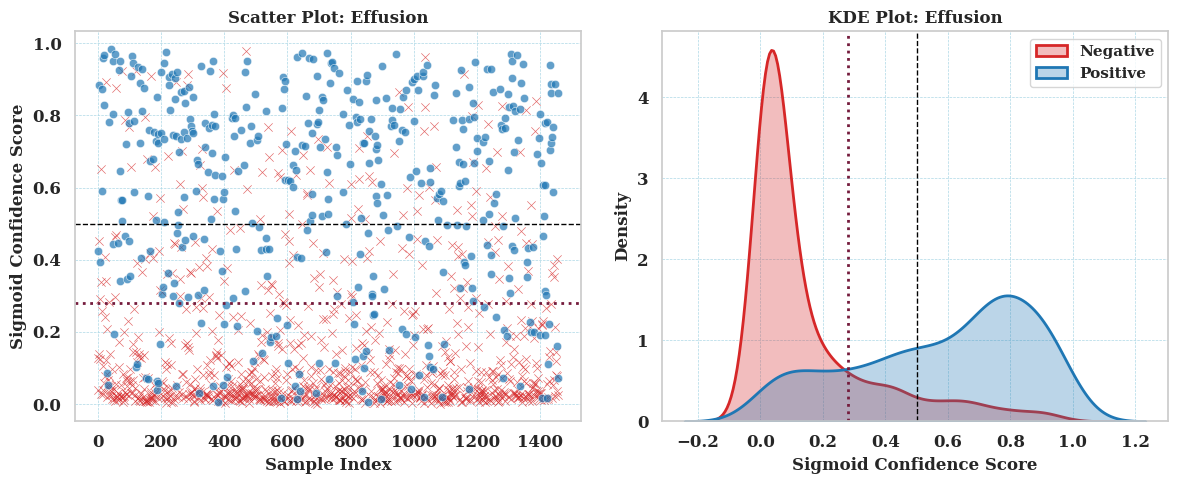

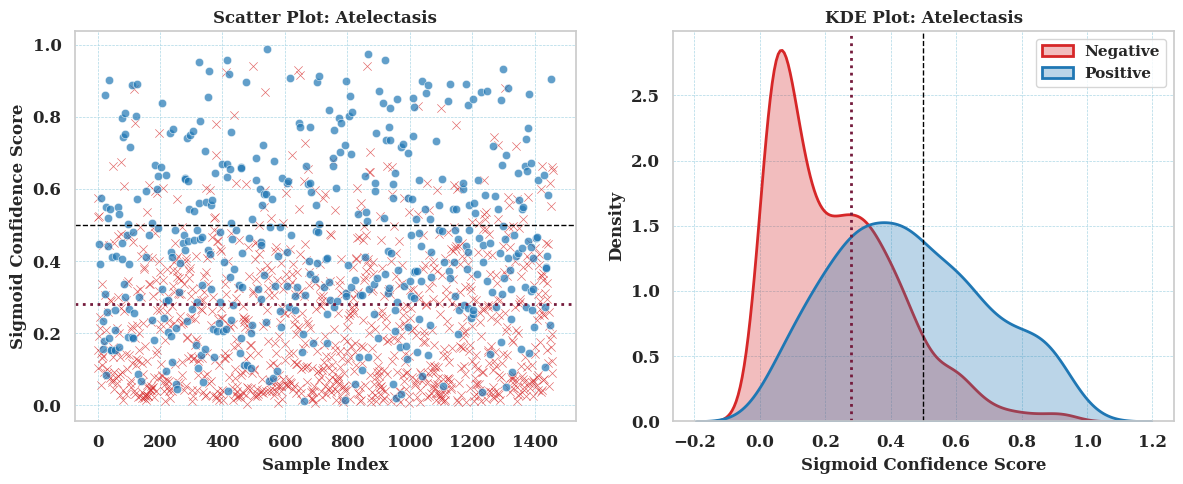

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    context='notebook',
    style='whitegrid',
    palette=sns.diverging_palette(220, 20, n=2),
    font='sans-serif',
    font_scale=1,
    color_codes=True,
    rc=None
)

def plot_kde_scatter_curves(probs, targets, best_threshold, labels=("Effusion", "Atelectasis"), save=False):
    plt.rcParams['axes.grid'] = True
    plt.rcParams['font.family'] = 'Serif'
    plt.rcParams['font.weight'] = 'bold'
    plt.rcParams['axes.labelweight'] = 'bold'
    plt.rcParams['axes.titleweight'] = 'bold'
    plt.rcParams['xtick.labelsize'] = 'medium'
    plt.rcParams['ytick.labelsize'] = 'medium'
    plt.rc('grid', linestyle='--', linewidth=0.5, color='lightblue')

    for i, label in enumerate(labels):
        p = probs[:, i]
        t = targets[:, i]

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        sns.scatterplot(x=np.arange(len(p))[t == 0], y=p[t == 0], marker='x', color="#d62728", alpha=0.7)
        sns.scatterplot(x=np.arange(len(p))[t == 1], y=p[t == 1], marker='o', color="#1f77b4", alpha=0.7)
        plt.axhline(y=0.5, linestyle="--", color="black", linewidth=1)
        plt.axhline(y=best_threshold, linestyle=":", color="#741B3C", linewidth=2)
        plt.xlabel("Sample Index", fontweight='bold')
        plt.ylabel("Sigmoid Confidence Score", fontweight='bold')
        plt.title(f"Scatter Plot: {label}", fontweight='bold')

        plt.subplot(1, 2, 2)
        sns.kdeplot(p[t == 0], label="Negative", fill=True, color="#d62728", alpha=0.3, linewidth=2)
        sns.kdeplot(p[t == 1], label="Positive", fill=True, color="#1f77b4", alpha=0.3, linewidth=2)
        plt.axvline(x=0.5, linestyle="--", color="black", linewidth=1)
        plt.axvline(x=best_threshold, linestyle=":", color="#741B3C", linewidth=2)
        plt.xlabel("Sigmoid Confidence Score", fontweight='bold')
        plt.ylabel("Density", fontweight='bold')
        plt.title(f"KDE Plot: {label}", fontweight='bold')
        plt.legend()

        plt.tight_layout()
        if save:
            plt.savefig(f"kde_scatter_{label.lower()}.pdf", format="pdf", bbox_inches="tight")
        plt.show()


plot_kde_scatter_curves(kde_probs, scatter_targets, best_thresh, save=False)

Split       Label   Loss  Precision  Recall  F1 Score  Accuracy  ROC AUC  PR AUC    MCC
 Full    Effusion 0.4473     0.7791  0.6732    0.7223    0.8354   0.8879  0.7797 0.6095
 Full Atelectasis 0.4473     0.6496  0.3985    0.4939    0.7520   0.7791  0.6106 0.3598
Train    Effusion 0.4301     0.7850  0.7065    0.7437    0.8507   0.8935  0.7832 0.6405
Train Atelectasis 0.4301     0.6424  0.4176    0.5062    0.7593   0.7929  0.6262 0.3708
 Test    Effusion 0.4488     0.7600  0.6376    0.6934    0.8273   0.8831  0.7619 0.5788
 Test Atelectasis 0.4488     0.6553  0.3986    0.4957    0.7587   0.7759  0.5993 0.3679

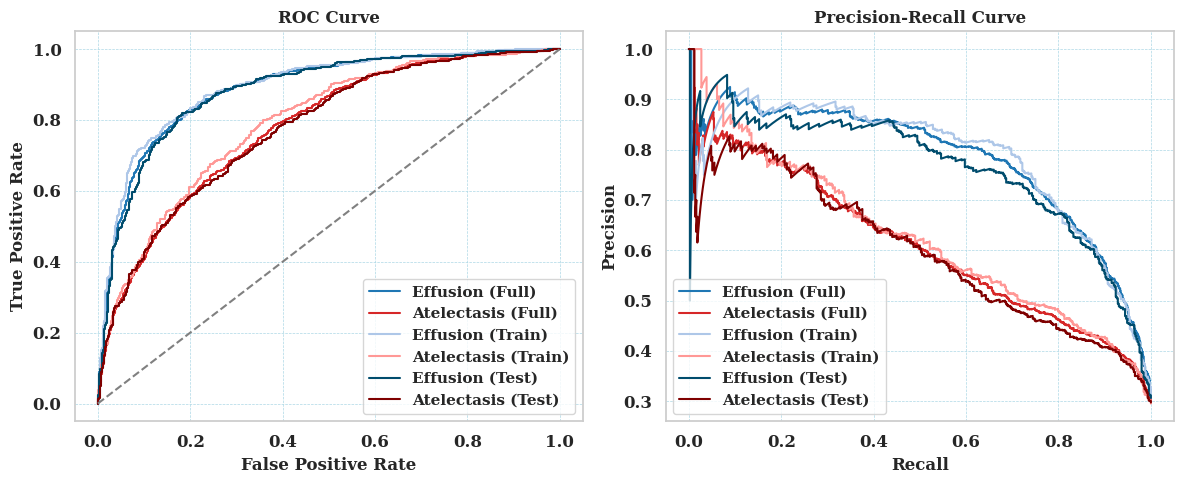

In [19]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    roc_curve,
    precision_recall_curve
)
import matplotlib.pyplot as plt

all_roc_data = []
all_pr_data = []
all_rows = []

color_map = {
    "Effusion (Full)": "#1f77b4",
    "Effusion (Train)": "#aec7e8",
    "Effusion (Test)": "#004c6d",
    "Atelectasis (Full)": "#d62728",
    "Atelectasis (Train)": "#ff9896",
    "Atelectasis (Test)": "#7f0000"
}

def print_prediction_stats(preds_tensor, targets_tensor, split_name, loss):
    probs = torch.sigmoid(preds_tensor).numpy()
    targets = targets_tensor.numpy()

    for i, label in enumerate(["Effusion", "Atelectasis"]):
        p = probs[:, i]
        t = targets[:, i]
        b = (p > 0.5).astype(int)

        all_rows.append({
            "Split": split_name,
            "Label": label,
            "Loss": round(loss, 4),
            "Precision": round(precision_score(t, b), 4),
            "Recall": round(recall_score(t, b), 4),
            "F1 Score": round(f1_score(t, b), 4),
            "Accuracy": round(accuracy_score(t, b), 4),
            "ROC AUC": round(roc_auc_score(t, p), 4),
            "PR AUC": round(average_precision_score(t, p), 4),
            "MCC": round(matthews_corrcoef(t, b), 4)
        })

        fpr, tpr, _ = roc_curve(t, p)
        prec, rec, _ = precision_recall_curve(t, p)

        all_roc_data.append((fpr, tpr, f"{label} ({split_name})"))
        all_pr_data.append((rec, prec, f"{label} ({split_name})"))

def show_combined_plots(save=False):
    df_stats = pd.DataFrame(all_rows)
    print("\n", df_stats.to_string(index=False), sep="")

    plt.rcParams['font.weight'] = 'bold'
    plt.rcParams['axes.labelweight'] = 'bold'
    plt.rcParams['axes.titleweight'] = 'bold'

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    for fpr, tpr, lbl in all_roc_data:
        plt.plot(fpr, tpr, label=lbl, color=color_map.get(lbl))
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title("ROC Curve", fontweight='bold')
    plt.xlabel("False Positive Rate", fontweight='bold')
    plt.ylabel("True Positive Rate", fontweight='bold')
    plt.legend()

    plt.subplot(1, 2, 2)
    for rec, prec, lbl in all_pr_data:
        plt.plot(rec, prec, label=lbl, color=color_map.get(lbl))
    plt.title("Precision-Recall Curve", fontweight='bold')
    plt.xlabel("Recall", fontweight='bold')
    plt.ylabel("Precision", fontweight='bold')
    plt.legend()

    plt.tight_layout()
    if save:
        plt.savefig("roc_pr_curves.pdf", format="pdf", bbox_inches="tight")
    plt.show()


print_prediction_stats(preds_full, targets_full, "Full", loss_full)
print_prediction_stats(preds_train, targets_train, "Train", loss_train)
print_prediction_stats(preds_test, targets_test, "Test", loss_test)

show_combined_plots(save=False)

## **Evaluate (eMatrix) Inferno Improvement**

| ⚙️ **Method**                    | ✅ **Advantages**                                                                                          | ❌ **Disadvantages**                                                                                   |
|----------------------------------|-------------------------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------------|
| 🧮 **Fixed Threshold (e.g., 0.5)** | - Very simple and fast<br>- Easy to implement and explain<br>- No additional computation required           | - Same threshold for all labels<br>- Ignores class imbalance<br>- Ignores prediction uncertainty<br>- No adaptation to task-specific costs |
| 🎯 **Per-Label Threshold Search**  | - Tailors threshold per label<br>- Can incorporate task-specific utility via validation<br>- Usually better than fixed threshold | - Treats labels independently<br>- Still relies on point estimates<br>- Slower due to validation loop |
| 🧠 **Inferno (Expected Utility)**  | - Makes joint predictions<br>- Incorporates uncertainty<br>- Uses full predictive distribution<br>- Directly maximizes expected utility<br>- Models label dependencies<br>- Especially suited for critical domains (e.g., medicine) | - Higher computational cost<br>- Requires proper probabilistic modeling and inference algorithms |

In [16]:
import subprocess
from pathlib import Path

RSCRIPT_PATH = Path("RScripts/utility.R")
WORKDIR = Path("..").resolve()

subprocess.run(["Rscript", str(RSCRIPT_PATH)], check=True, cwd=WORKDIR)



Registered doParallelSNOW with 10 workers

Closing connections to cores.
🔍 Average Expected Utility from Inferno Decisions: 0.918163 

📊 Confusion Matrix - Effusion
    Pred
True   0   1
   0 847 165
   1  96 351

📊 Confusion Matrix - Atelectasis
    Pred
True   0   1
   0 669 356
   1 130 304


CompletedProcess(args=['Rscript', 'RScripts/utility.R'], returncode=0)

## 🧪 Confusion Matrix Comparison and Performance Summary

### 📋 Combined Confusion Matrices for CNN & Inferno

| Model   | Threshold | Disease     | TP  | FP  | FN  | TN  |
|---------|-----------|-------------|-----|-----|-----|-----|
| CNN     | 0.50      | Effusion    | 285 |  90 | 162 | 922 |
| CNN     | 0.50      | Atelectasis | 173 |  91 | 261 | 934 |
| CNN     | 0.28      | Effusion    | 366 | 185 |  81 | 827 |
| CNN     | 0.28      | Atelectasis | 323 | 371 | 111 | 654 |
| Inferno | -         | Effusion    | 351 | 165 |  96 | 847 |
| Inferno | -         | Atelectasis | 304 | 356 | 130 | 669 |


### 📊 Performance Summary

CNN at threshold 0.50 provides a more conservative decision boundary with lower false positives but also higher false negatives, particularly in Atelectasis.

CNN at threshold 0.28 boosts recall significantly (TP increases), but at the cost of many more false positives, especially for Atelectasis.

Inferno offers a well balanced tradeoff between sensitivity and specificity across both diseases:
- Outperforms CNN on average utility: 0.9182 vs 0.9077
- Achieves higher TP counts than CNN at 0.50, and fewer FP/FN than CNN at 0.28
- Suggests robust calibration and confidence aware decision making without threshold tuning

### ✅ Conclusion

Inferno demonstrates improved utility and a more balanced performance profile, making it a compelling option for deployment in scenarios where reliable probabilistic decision making is important. In contrast, CNN provides flexibility through threshold adjustment but depends heavily on careful tuning to manage tradeoffs between sensitivity and specificity.